In [2]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Maintainance Dataset:-

In [3]:
maintain = pd.read_csv(r"/Users/nexusop03/Downloads/maintenance_data.csv")
maintain

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


In [4]:
print(maintain.info)

<bound method DataFrame.info of      lifetime  broken  pressureInd  moistureInd  temperatureInd   team  \
0          56       0    92.178854   104.230204       96.517159  TeamA   
1          81       1    72.075938   103.065701       87.271062  TeamC   
2          60       0    96.272254    77.801376      112.196170  TeamA   
3          86       1    94.406461   108.493608       72.025374  TeamC   
4          34       0    97.752899    99.413492      103.756271  TeamB   
..        ...     ...          ...          ...             ...    ...   
995        88       1    88.589759   112.167556       99.861456  TeamB   
996        88       1   116.727075   110.871332       95.075631  TeamA   
997        22       0   104.026778    88.212873       83.221220  TeamB   
998        78       0   104.911649   104.257296       83.421491  TeamA   
999        63       0   116.901354    99.998694       47.641493  TeamB   

      provider  
0    Provider4  
1    Provider4  
2    Provider1  
3    Provid

In [5]:
print(maintain.isnull().sum())

lifetime          0
broken            0
pressureInd       0
moistureInd       0
temperatureInd    0
team              0
provider          0
dtype: int64


In [6]:
d=maintain.describe(include = 'all')
d

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,NaN,NaN,NaN,3,4
top,NaN,NaN,NaN,NaN,NaN,TeamB,Provider2
freq,NaN,NaN,NaN,NaN,NaN,356,266
mean,55.195000,0.397000,98.599338,99.376723,100.628541,NaN,NaN
std,26.472737,0.489521,19.964052,9.988726,19.633060,NaN,NaN
min,1.000000,0.000000,33.481917,58.547301,42.279598,NaN,NaN
25%,34.000000,0.000000,85.558076,92.771764,87.676913,NaN,NaN
50%,60.000000,0.000000,97.216997,99.433959,100.592277,NaN,NaN
75%,80.000000,1.000000,112.253190,106.120762,113.662885,NaN,NaN


In [7]:
import warnings 
warnings.filterwarnings("ignore")

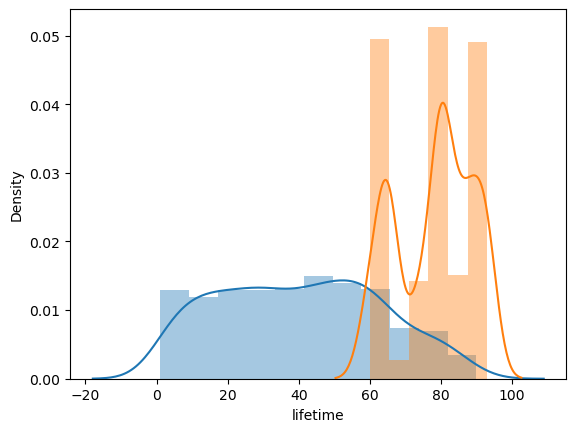

In [8]:
sns.distplot(maintain.lifetime[maintain.broken == 0])
sns.distplot(maintain.lifetime[maintain.broken == 1])
plt.show()

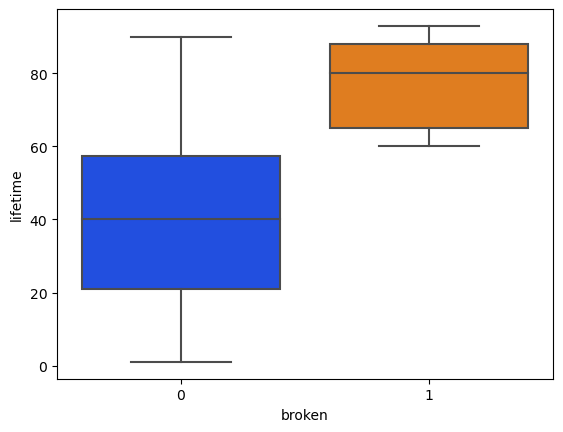

In [9]:
sns.boxplot(x = maintain.broken, y = maintain.lifetime, palette = 'bright')
plt.show()

# Encoding:- It converts string data to numeric
## Types of encoding:-
<pre>
    <b><i>
        1.Label Encoding     
        2.One-hot Encoding
        3.Ordinal Encoding
        4.Frequency Encoding
        5.Dummy Encoding
        6.Target/ Mean Encoding
    </i></b>
    Mostly we use label encoding and One-Hot Encoding.
</pre>

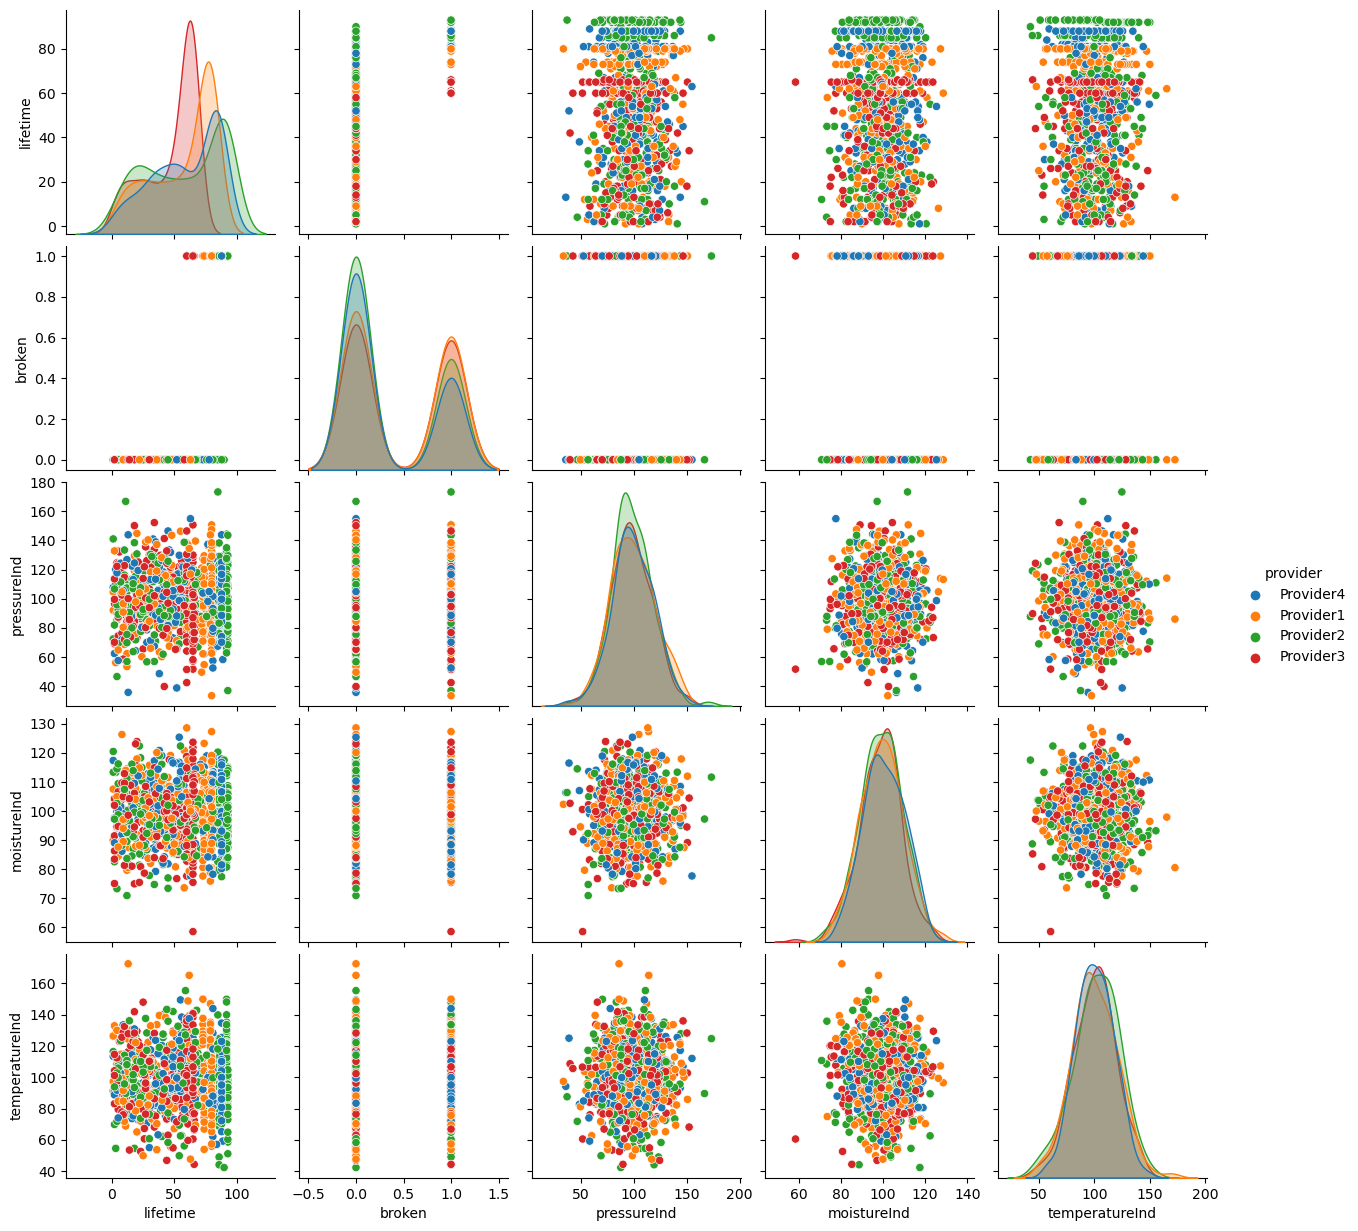

In [10]:
sns.pairplot(maintain, hue = 'provider')
plt.show()

# Label Encoding:-

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le

LabelEncoder()

In [12]:
maintain.team = le.fit_transform(maintain.team)
maintain.team.unique()

array([0, 2, 1])

In [13]:
# to know what is array([0, 2, 1]) We have to inverse this.
le.inverse_transform([0,2,1])

array(['TeamA', 'TeamC', 'TeamB'], dtype=object)

In [14]:
maintain.provider = le.fit_transform(maintain.provider)
maintain.provider.unique()

array([3, 0, 1, 2])

In [15]:
le.inverse_transform([3, 0, 1, 2])

array(['Provider4', 'Provider1', 'Provider2', 'Provider3'], dtype=object)

In [16]:
maintain

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,0,3
1,81,1,72.075938,103.065701,87.271062,2,3
2,60,0,96.272254,77.801376,112.196170,0,0
3,86,1,94.406461,108.493608,72.025374,2,1
4,34,0,97.752899,99.413492,103.756271,1,0
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,1,3
996,88,1,116.727075,110.871332,95.075631,0,3
997,22,0,104.026778,88.212873,83.221220,1,0
998,78,0,104.911649,104.257296,83.421491,0,3


In [17]:
c = maintain.corr()
c

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
lifetime,1.000000,0.702656,0.000943,0.001196,0.001744,-0.046537,-0.025172
broken,0.702656,1.000000,-0.028942,-0.019520,0.015364,0.030876,-0.062972
pressureInd,0.000943,-0.028942,1.000000,0.020543,0.003641,-0.069528,-0.004337
moistureInd,0.001196,-0.019520,0.020543,1.000000,-0.009842,0.022420,0.028906
temperatureInd,0.001744,0.015364,0.003641,-0.009842,1.000000,0.007310,-0.010822
team,-0.046537,0.030876,-0.069528,0.022420,0.007310,1.000000,0.005606
provider,-0.025172,-0.062972,-0.004337,0.028906,-0.010822,0.005606,1.000000


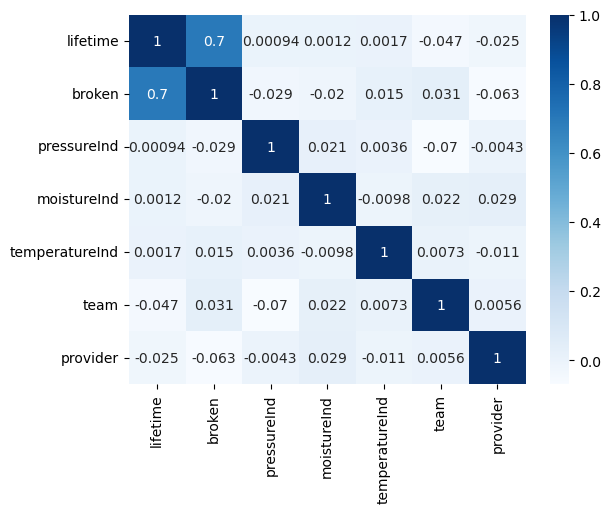

In [18]:
sns.heatmap(c ,annot = True , cmap = 'Blues')
plt.show()

# I/O creation:-

In [19]:
ip = maintain.drop('broken',axis=1)
op = maintain.broken

# Train Test Split:-

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train, y_test = train_test_split(ip,op,test_size =0.2,random_state= 300)

In [21]:
x_train

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
74,4,107.837359,99.838172,111.084853,1,3
330,71,105.971448,87.367487,106.551715,1,1
47,15,75.646693,114.198857,86.817937,2,0
249,74,75.815981,106.123770,96.253609,2,0
541,56,87.513218,115.461282,104.024233,0,3
...,...,...,...,...,...,...
9,81,99.178235,99.138717,95.492965,2,3
714,8,102.528555,109.669689,125.603284,2,2
917,60,122.108776,98.824569,96.968692,2,2
481,35,70.959022,91.056107,83.545443,1,1


In [22]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(800, 6)
(800,)
(200, 6)
(200,)


In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [24]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [25]:
pred = lr.predict(x_test)
pred

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1])

# Confusion Matrix:-
<pre>It is used to measure performance of the classification of the model.
     
</pre>

## Accuracy :- 
<pre>it is defined as the ratio betweem the current prediction and all preiction.
    
<b>Accuracy = (TP + TN )/ (TP + TN + FP + FN)</b>
</pre>
## Recall:-
<pre>
It is defined as prediction i.e actually positive divided by all the actual yes cases. 
   <b> Recall = TP / (TP + FN)</b>
</pre>
## Precision:-
<pre>
It is defined as prediction i.e actually positive divided by all the predicted yes cases.
<b>Perecision = TP /(TP+FP)<b/>
</pre>
## F1 Score:-
<pre>
It is defined as the reciprocal of the reciprocal
</pre>
<b>F1_score = (((precision<sup>-1</sup> + Recall<sup>-1</sup>) / 2))<sup>-1</sup> = 2* precision * recall / (precision<sup>-1</sup> + Recall<sup>-1</sup>)
</b>

In [26]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

ac = accuracy_score(y_test,pred)
re = recall_score(y_test,pred)
pr = precision_score(y_test,pred)
f1 = f1_score(y_test,pred)
print('accuracy' , ac)
print('recall' , re)
print('precision_scorely',pr)
print('f1_score', f1)


accuracy 0.83
recall 0.7466666666666667
precision_scorely 0.7887323943661971
f1_score 0.767123287671233


In [27]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test,pred)
cm

array([[110,  15],
       [ 19,  56]])

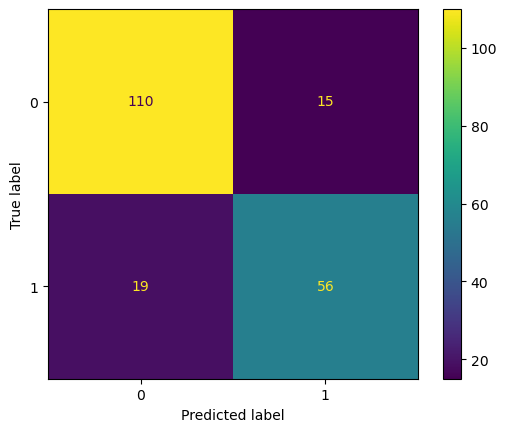

In [28]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [29]:
df = pd.DataFrame({"Y_test":list(y_test),"Prediction":pred})
df

,Y_test,Prediction
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
...,...,...
195,1,1
196,1,1
197,1,1
198,0,0


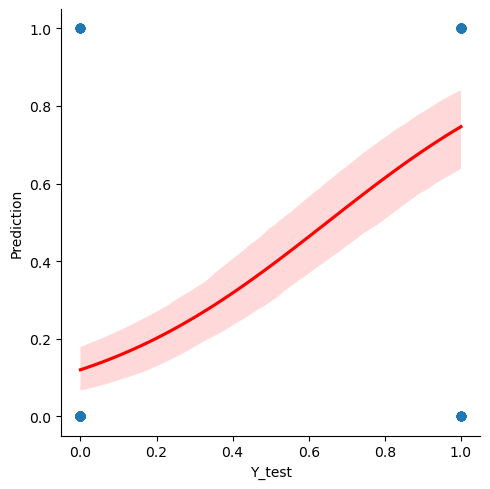

In [30]:
sns.lmplot(x = 'Y_test',y = 'Prediction',data = df, logistic = True, line_kws = {'color':'r'})
plt.show()

# KNN(K-Nearest Neighbor):-
<pre>
    K = no. of nearest Neighbors
    n_neighbor<i>(kitna neighbor hai uske aas paas)</i>ka value always odd and positive lena hai.
    n_neighbor ka default value 5 leta hai system.
    
</pre>

In [31]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= 7)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [32]:
pred1 = knn.predict(x_test)
pred1

array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1])

In [33]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

ac = accuracy_score(y_test,pred1)
re = recall_score(y_test,pred1)
pr = precision_score(y_test,pred1)
f1 = f1_score(y_test,pred1)
print('accuracy:        ' , ac)
print('recall:          ' , re)
print('precision_score: ',pr)
print('f1_score:        ', f1)


accuracy:         0.83
recall:           0.8133333333333334
precision_score:  0.7530864197530864
f1_score:         0.782051282051282


In [34]:
cm = confusion_matrix(y_test,pred1)
cm

array([[105,  20],
       [ 14,  61]])

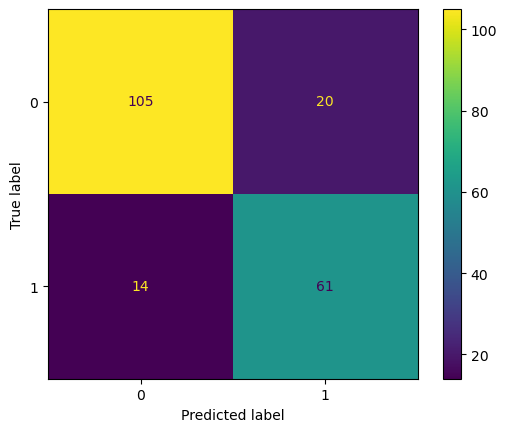

In [35]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [36]:
df = pd.DataFrame({"Y_test":list(y_test),"Prediction":pred1})
df

,Y_test,Prediction
0,1,1
1,0,0
2,1,1
3,0,1
4,0,0
...,...,...
195,1,1
196,1,0
197,1,1
198,0,0


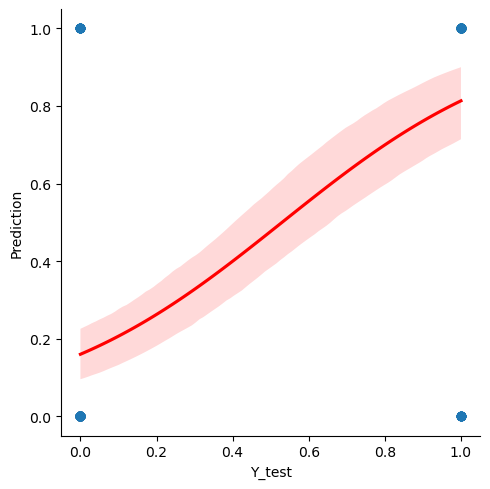

In [37]:
sns.lmplot(x = 'Y_test',y = 'Prediction',data = df, logistic = True, line_kws = {'color':'r'})
plt.show()

# Naive Bayes:-
<pre>This is based upon Bayes Theorem.
     1.Gaussian Naive Bayes(Both Numeric and text)
     2.Multinomial Naive Bayes(Only text)
     3.Bernouli Naive Bayes(Only Catgorical)
</pre>

In [38]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [39]:
pred2 = gnb.predict(x_test)
pred2

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1])

In [40]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

ac = accuracy_score(y_test,pred2)
re = recall_score(y_test,pred2)
pr = precision_score(y_test,pred2)
f1 = f1_score(y_test,pred2)
print('accuracy:        ' , ac)
print('recall:          ' , re)
print('precision_score: ',pr)
print('f1_score:        ', f1)


accuracy:         0.86
recall:           0.8666666666666667
precision_score:  0.7831325301204819
f1_score:         0.8227848101265823


In [41]:
cm = confusion_matrix(y_test,pred2)
cm

array([[107,  18],
       [ 10,  65]])

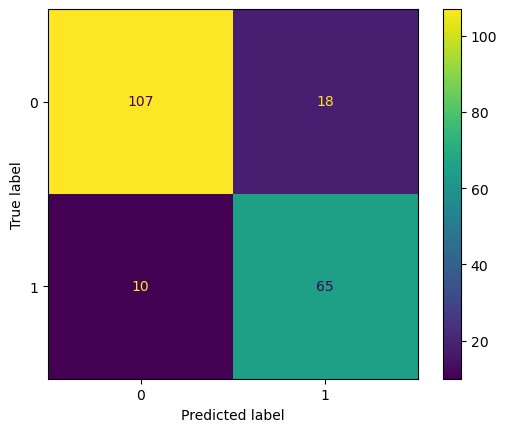

In [42]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [43]:
df = pd.DataFrame({"Y_test":list(y_test),"Prediction":pred2})
df

,Y_test,Prediction
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
...,...,...
195,1,1
196,1,1
197,1,1
198,0,0


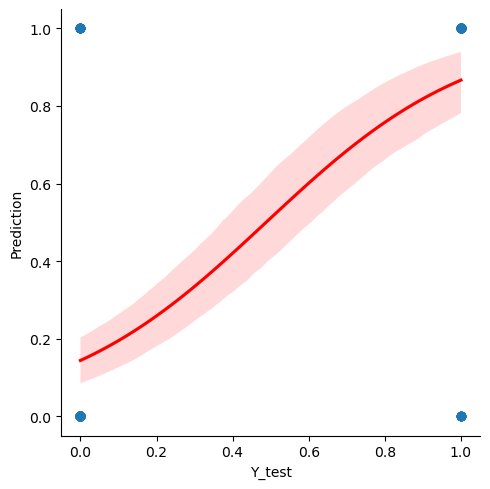

In [44]:
sns.lmplot(x = 'Y_test',y = 'Prediction',data = df, logistic = True, line_kws = {'color':'r'})
plt.show()

# DATE - 17/06/26

# SVM(Support Vector Machine):-
## SVC(Support Vector Classifier):-
<pre><i>
    The main role of the SVM / SVC(Support Vector Classifier) is to create decision boundary or support vector to segregate the data in diff. classes,so that we can easily put new data point in the correct class.
</i>
         <b>Kernel Function:-</b>

   <i> It is divided into 4 types.
    1) Linear:- 1D-2D
    2) Poly:- 2D-3D
    3) Sigmoid:- 2D-3D
    4) RBF(Radial Basis Function):- 1D-2D-3D

    -> Gamma is the co-efficient of Kernerl Function.It decides how tightly the decision bundary fit to the data
   </i> 
</pre>

In [45]:
from sklearn.svm import SVC
svc = SVC(kernel ='rbf', gamma = 0.03, C = 1000)
svc.fit(x_train,y_train)

SVC(C=1000, gamma=0.03)

In [46]:
pred3 = svc.predict(x_test)
pred3

array([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1])

In [47]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

ac = accuracy_score(y_test,pred3)
re = recall_score(y_test,pred3)
pr = precision_score(y_test,pred3)
f1 = f1_score(y_test,pred3)
print('accuracy:        ' , ac)
print('recall:          ' , re)
print('precision_score: ',pr)
print('f1_score:        ', f1)


accuracy:         0.935
recall:           1.0
precision_score:  0.8522727272727273
f1_score:         0.9202453987730062


In [48]:
cm = confusion_matrix(y_test,pred3)
cm

array([[112,  13],
       [  0,  75]])

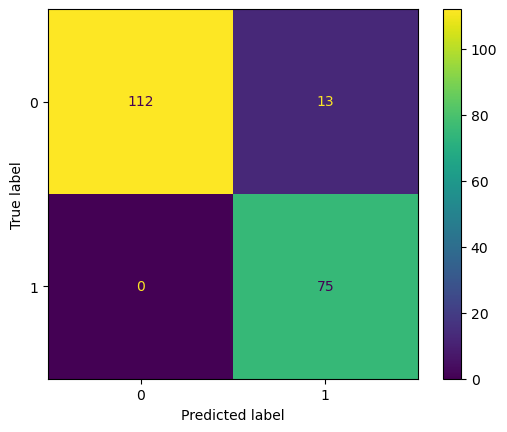

In [49]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [52]:
df = pd.DataFrame({"Y_test":list(y_test),"Prediction":pred3})
df

,Y_test,Prediction
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
...,...,...
195,1,1
196,1,1
197,1,1
198,0,0


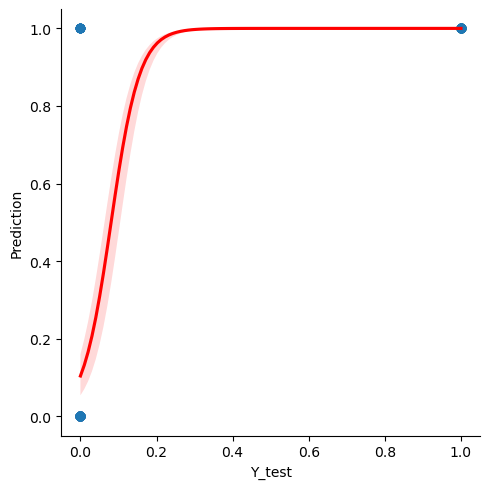

In [53]:
sns.lmplot(x = 'Y_test',y = 'Prediction',data = df, logistic = True, line_kws = {'color':'r'})
plt.show()

## important:-
agar humein prediction,accuracy,recall score aur f1 score nikalna hai toh pehle encoding karke standard scalar tak karna hoga phir koi bhi algo use karenge toh uska o/p mil jayega

# Unsupervised Machine Learning:-
<pre>
    It is two types:-1)Clustering
                     2)Associative

</pre>
### Clustering:-
<pre>
    1) K-means Clustering
    2) Agglomarative Clustering
    3) Hierarchical Clustering
    4) Fuzzy
</pre>

### Associative:-
<pre>
    1) PCA(Principal Component Analysis)
    2) LDA(Liner Discriminant Analysis)
</pre>